In [16]:
import numpy as np
import matplotlib.pyplot as plt

In [17]:
# Segunda version (Una forma mas eficiente para implemnetar el algoritmo)

def egaussp(A, b):
    n = A.shape[0]
    # Salidas
    U = A.copy()
    y = b.copy()

    for k in range(n-1):
        if max(np.abs(U[k:, k]))!=0: # Vemos si vale la pena aplicar Gauss a la columna U[k:, k]
                                     # Si llega a dar cero entonces no hace falta aplicar Gauss ya que
                                     # tenemos la columna nula por debajo de la diagonal principal
                                     # que es lo que queremos

            l = k + np.argmax((np.abs(U[k:, k]))) # np.argmax me permite encontrar el indice del elemento
                                                  # con mayor valor absoluto

            U[[k, l], :] = U[[l, k], :] # Directamente hacemos el intercambio de filas en U e y
            y[[k, l]] = y[[l, k]]       # Este intercambio no tiene un costo computacional
                                        # Nos evita realizar operaciones de producto en punto flotante
                                        # como por ejemplo P@U y P@y

            # A partir de aqui el algoritmo se repite igual que el de egauss_1
            v = U[k+1:, k]/U[k,k]
            U[k+1:, k] = 0
            U[k+1:, k+1:] = U[k+1:, k+1:] - np.outer(v, U[k, k+1:])
            y[k+1:] = y[k+1:] - v*y[k]

    return U, y

def sol_trsupcol(A, b):
    n = len(b)
    x = b.copy()

    for idx in reversed(range(n)):
        if b[idx] != 0:
            j = idx
            break

    for i in reversed(range(j + 1)):
        x[i] = x[i] / A[i, i]
        x[:i] = x[:i] - A[:i, i] * x[i]

    return x
def sol_egauss(A, b):
    U, y = egaussp(A,b)
    x = sol_trsupcol(U, y)
    return x

Tenemos la siguiente ecuación de una circunferencia
$$
x^2+y^2+ax+by+c=0
$$
Definimos 3 puntos de $\mathbb{R}^2$:
$$u = (u_1, u_2),\; v = (v_1, v_2),\; w = (w_1, w_2)$$

Armamos el sistema de ecuaciones para estos 3 puntos:

$$
\begin{cases}
u_1^2+u_2^2 + au_1 + bu_2 + c = 0\\
v_1^2+v_2^2 + av_1 + bv_2 + c = 0\\
w_1^2+w_2^2 + aw_1 + bw_2 + c = 0
\end{cases}
$$
Reacomodando el sistema nos queda,
$$
\begin{cases}
au_1 + bu_2 + c = -(u_1^2+u_2^2)\\
 av_1 + bv_2 + c = -(v_1^2+v_2^2)\\
 aw_1 + bw_2 + c = -(w_1^2+w_2^2)
\end{cases}
$$
donde $a$, $b$ y $c$ son las incógnitas a determinar.

Ya tenemos nuestro sistema nos falta saber el radio de la circunferencias;

$$
\begin{array}{cc}
x^2+y^2+ax+by+c & = &0\\
x^2+ax+\dfrac{a^2}{4}-\dfrac{a^2}{4}+y^2+by+\dfrac{b^2}{4}-\dfrac{b^2}{4}+c & = & 0\\
\left(x+\dfrac{a}{2}\right)^2+\left(y+\dfrac{b}{2}\right)^2& = & \dfrac{a^2+b^2}{4}-c\\
\left(x+\dfrac{a}{2}\right)^2+\left(y+\dfrac{b}{2}\right)^2& = & r^2\\
\end{array}
$$

Luego, $r = \sqrt{\dfrac{a^2+b^2}{4}-c}$. Ahora pasamos a gráficar la circuenferencia con los tres puntos.

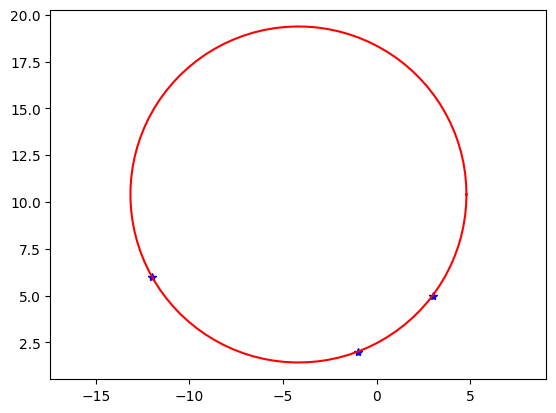

In [15]:
def graficar_circunferencia(u, v, w):
    # chequear no colinealidad? en teoria si fueran colineales no podríamos resolver el sistema...

    # Armar sistema
    A = np.array([
        [u[0],u[1],1],
        [v[0],v[1],1],
        [w[0],w[1],1],
    ]).astype("float")

    b = - np.array([u[0]**2 + u[1]**2, v[0]**2 + v[1]**2, w[0]**2 + w[1]**2]).astype("float")

    # x = [a, b, c]
    x = sol_egauss(A, b)

    # graficar puntos
    plt.plot(u[0], u[1], "*b", v[0], v[1], "*b", w[0], w[1], "*b")

    # armar circunferencia a partir de muchos puntos entre 0 y 2pi
    circunferencia = np.linspace(0, 2 * np.pi, 100)

    radio = np.sqrt((x[0]**2 + x[1]**2) / 4 - x[2])
    # trasladar la circunferencia al punto central
    x_circunferencia = radio*(np.cos(circunferencia)) - x[0] / 2
    y_circunferencia = radio*(np.sin(circunferencia)) - x[1] / 2

    plt.plot(x_circunferencia, y_circunferencia, "r")
    # ejes con misma escala
    plt.axis("equal")
    plt.show()

graficar_circunferencia((3,5), (-1,2), (-12,6))